## ① Normal Large Gap 구조 검증

`dt_sec > 0.15`인 구간을 제거하거나 보간하지 않고, 간격 분포·발생 행 간 거리·gap 전후의 원본 신호를 함께 확인한다. 분석 결과는 저장/수집 block 구조와 실제 운전 단절을 구별할 수 있는 증거가 있는지 평가하는 용도이며, 원인을 확정하지 않는다.


All timestamp intervals (sec):


,count,min,Q1,median,mean,Q3,95%,max
Normal,19998.0,0.1,0.1,0.1,0.230814,0.1,0.1,16.643
Outlier,599.0,0.1,0.1,0.1,0.276456,0.1,0.1,8.572


Large gap intervals only (dt_sec > 0.15 sec):


,count,min,Q1,median,mean,Q3,95%,max
Normal,598.0,1.545,2.4065,4.2225,4.474597,5.80825,8.55975,16.643
Outlier,20.0,1.780,3.4415,5.3525,5.384850,7.80375,8.54730,8.572


Normal: rounded gap value counts (0.1 sec resolution)
rounded_dt_sec
1.5      1
1.6      6
1.7     31
1.8     40
1.9     30
2.0     16
2.1      8
2.2      7
2.3      7
2.4     10
2.5      7
2.6      4
2.7      5
2.8      7
2.9     11
3.0     14
3.1     11
3.2     16
3.3      8
3.4      8
3.5      7
3.6      6
3.7      6
3.8      9
3.9      6
4.0      7
4.1      5
4.2     12
4.3      8
4.4     12
4.5      7
4.6     18
4.7      9
4.8      8
4.9      5
5.0      8
5.1      4
5.2      7
5.3      9
5.4      8
5.5     14
5.6      8
5.7      9
5.8     12
5.9     12
6.0      6
6.1      7
6.2      5
6.3      6
6.4      8
6.5      7
6.6      5
6.7      5
6.8      5
6.9      4
7.3      3
7.5      1
7.7      1
7.8      1
8.0      1
8.3      6
8.4     13
8.5     18
8.6     11
8.7      6
8.8      5
8.9      1
9.7      3
9.8      1
15.3     1
15.4     1
16.5     2
16.6     2
Outlier: rounded gap value counts (0.1 sec resolution)
rounded_dt_sec
1.8    1
2.0    1
2.6    1
2.8    1
3.2    1
3.5    1
4.0 

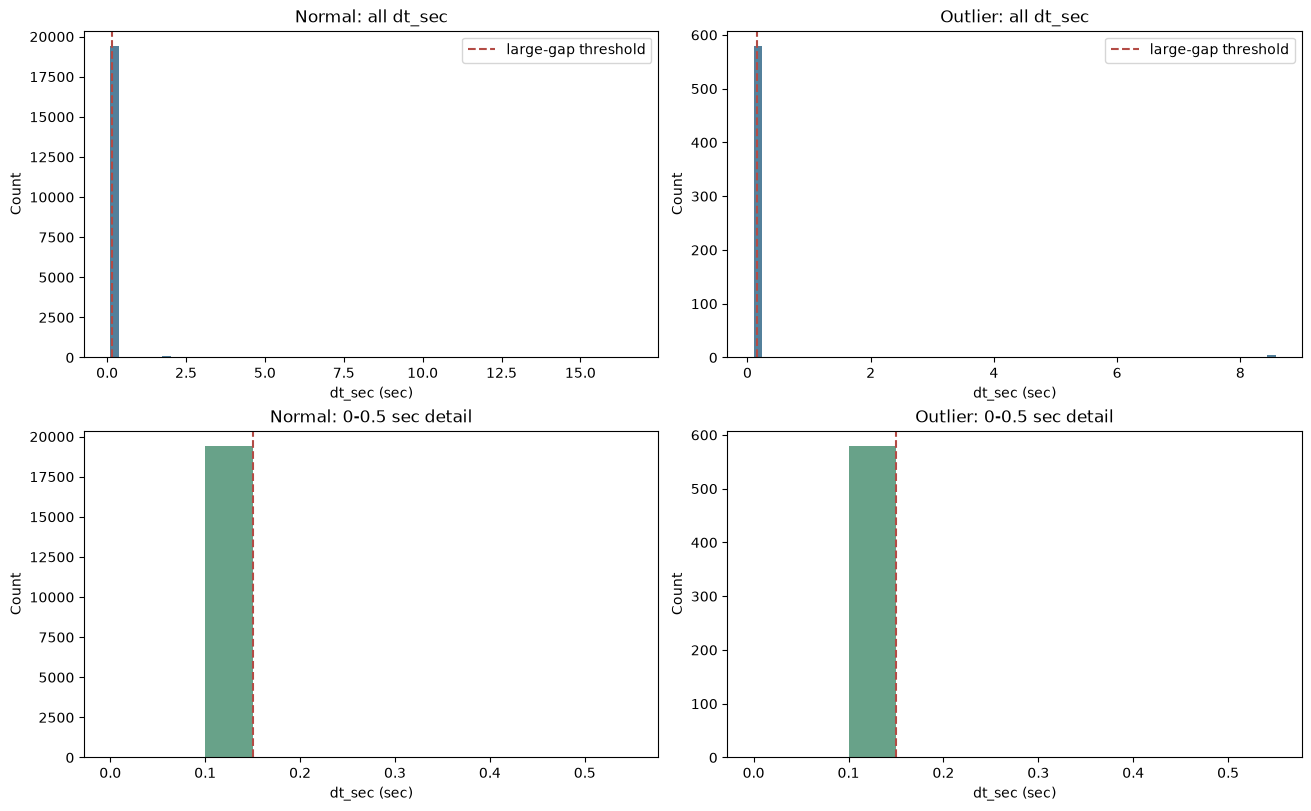

In [ ]:
GAP_THRESHOLD_SEC = 0.15
GAP_DATASETS = {"Normal": normal, "Outlier": outlier}

def interval_summary(values):
    values = values.dropna()
    return pd.Series({
        "count": values.count(),
        "min": values.min(),
        "Q1": values.quantile(0.25),
        "median": values.median(),
        "mean": values.mean(),
        "Q3": values.quantile(0.75),
        "95%": values.quantile(0.95),
        "max": values.max(),
    })

all_dt_summary = pd.DataFrame({name: interval_summary(df["dt_sec"]) for name, df in GAP_DATASETS.items()}).T
print("All timestamp intervals (sec):")
display(all_dt_summary)

large_gap_summary = pd.DataFrame({
    name: interval_summary(df.loc[df["dt_sec"].gt(GAP_THRESHOLD_SEC).fillna(False), "dt_sec"])
    for name, df in GAP_DATASETS.items()
}).T
print(f"Large gap intervals only (dt_sec > {GAP_THRESHOLD_SEC} sec):")
display(large_gap_summary)

for name, df in GAP_DATASETS.items():
    gaps = df.loc[df["dt_sec"].gt(GAP_THRESHOLD_SEC).fillna(False), "dt_sec"]
    print(f"{name}: rounded gap value counts (0.1 sec resolution)")
    print(gaps.round(1).value_counts().sort_index().rename_axis("rounded_dt_sec").to_string())

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
for col, (name, df) in enumerate(GAP_DATASETS.items()):
    dt_values = df["dt_sec"].dropna()
    axes[0, col].hist(dt_values, bins=60, color="#356a8a", alpha=0.85)
    axes[0, col].axvline(GAP_THRESHOLD_SEC, color="#b34b45", linestyle="--", label="large-gap threshold")
    axes[0, col].set(title=f"{name}: all dt_sec", xlabel="dt_sec (sec)", ylabel="Count")
    axes[0, col].legend()
    axes[1, col].hist(dt_values, bins=np.arange(0, 0.56, 0.05), color="#4d9274", alpha=0.85)
    axes[1, col].axvline(GAP_THRESHOLD_SEC, color="#b34b45", linestyle="--")
    axes[1, col].set(title=f"{name}: 0-0.5 sec detail", xlabel="dt_sec (sec)", ylabel="Count")
plt.show()

In [ ]:
gap_position_tables = {}
for name, df in GAP_DATASETS.items():
    gap_mask = df["dt_sec"].gt(GAP_THRESHOLD_SEC).fillna(False)
    gap_rows = df.loc[gap_mask, "source_row"].astype(int).to_numpy()
    row_distance = np.diff(gap_rows)
    table = pd.DataFrame({"gap_source_row": gap_rows})
    table["previous_gap_row_distance"] = np.r_[np.nan, row_distance]
    gap_position_tables[name] = table
    print(f"{name}: gap source rows and distance from previous gap")
    with pd.option_context("display.max_rows", None, "display.max_columns", None):
        display(table)
    print("Row-distance value counts:")
    display(pd.Series(row_distance, name="row_distance").value_counts().sort_index().to_frame())
    if len(row_distance):
        print(
            f"Median row distance={np.median(row_distance):.1f}; "
            f"exactly 50 rows={np.mean(row_distance == 50):.1%}; "
            f"within 45-55 rows={np.mean((row_distance >= 45) & (row_distance <= 55)):.1%}"
        )
        print("Gap source row modulo 50:")
        display(pd.Series(gap_rows % 50, name="source_row_mod_50").value_counts().sort_index().to_frame())

Normal: gap source rows and distance from previous gap


,gap_source_row,previous_gap_row_distance
0,41,NaN
1,78,37.0
2,102,24.0
3,112,10.0
4,162,50.0
5,212,50.0
6,262,50.0
7,303,41.0
8,329,26.0
9,342,13.0


Row-distance value counts:


,count
row_distance,
1,9
2,6
3,9
4,5
5,5
6,7
7,8
8,12
9,8


Median row distance=37.0; exactly 50 rows=33.8%; within 45-55 rows=39.5%
Gap source row modulo 50:


...

,gap_source_row,previous_gap_row_distance
0,4,NaN
1,54,50.0
2,101,47.0
3,132,31.0
4,150,18.0
5,153,3.0
6,203,50.0
7,243,40.0
8,268,25.0
9,276,8.0


Row-distance value counts:


,count
row_distance,
3,1
4,1
8,1
10,1
15,1
18,1
24,1
25,1
28,1


Median row distance=31.0; exactly 50 rows=26.3%; within 45-55 rows=31.6%
Gap source row modulo 50:


,count
source_row_mod_50,
0,2
1,2
3,2
4,2
15,3
18,1
22,1
25,1
26,1


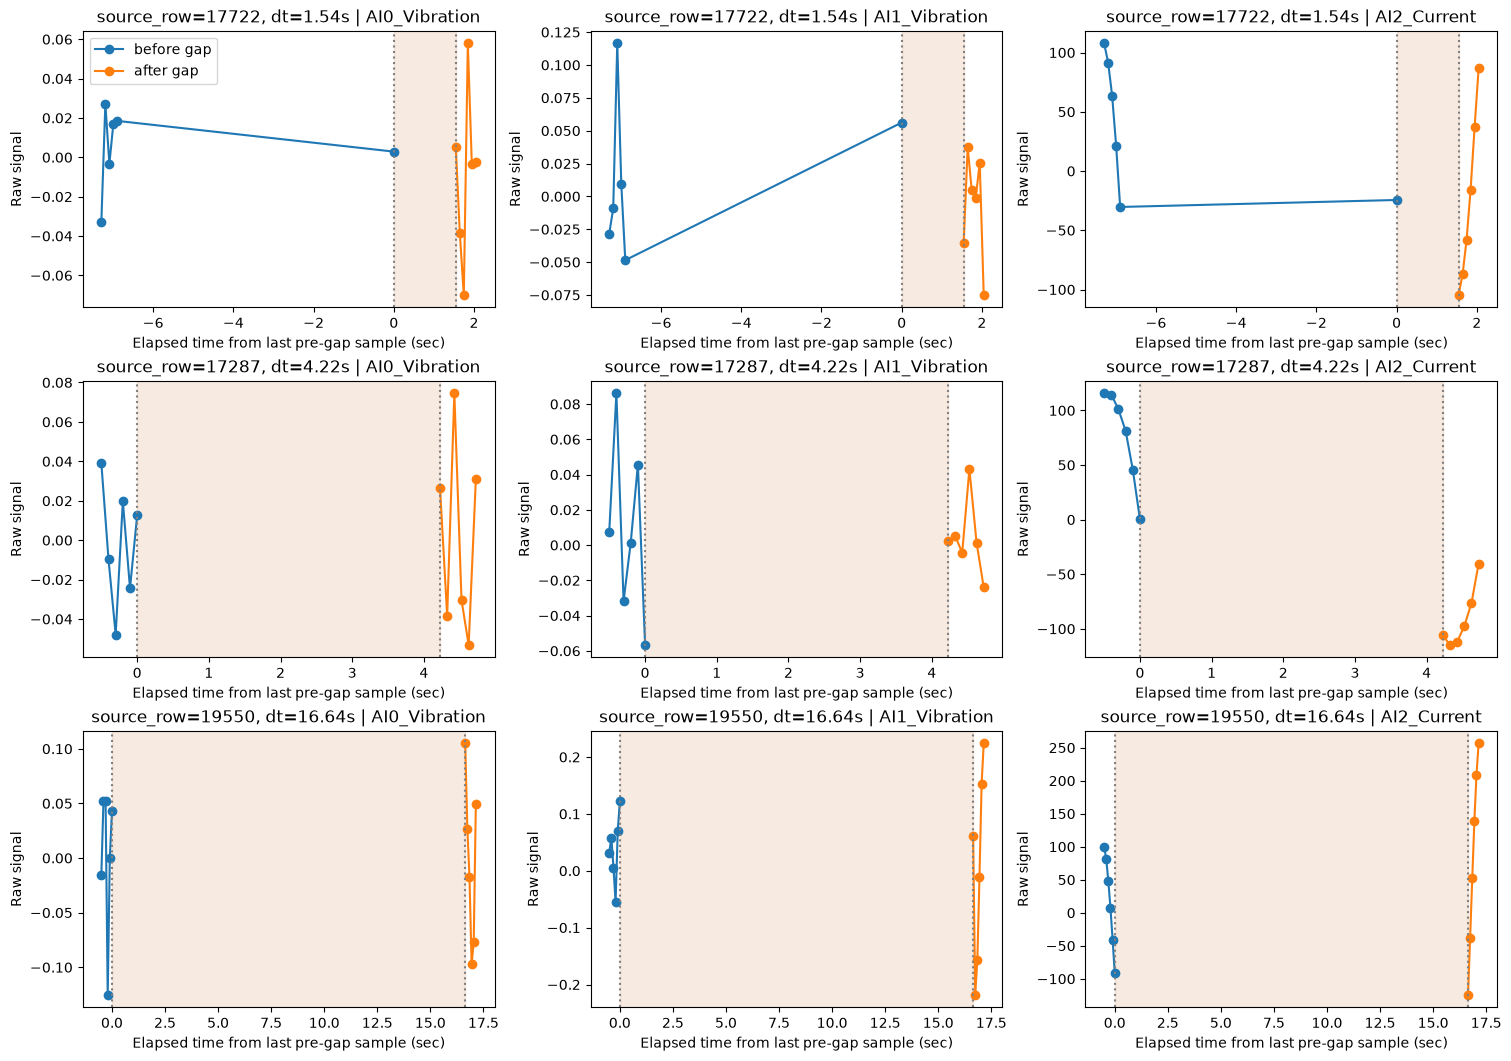

Gap windows show raw samples on both sides without drawing a line through the missing interval.


In [ ]:
normal_gap_mask = normal["dt_sec"].gt(GAP_THRESHOLD_SEC).fillna(False)
normal_gap_rows = np.flatnonzero(normal_gap_mask.to_numpy(dtype=bool))
if len(normal_gap_rows):
    normal_gap_durations = normal.loc[normal_gap_mask, "dt_sec"]
    target_values = [normal_gap_durations.min(), normal_gap_durations.median(), normal_gap_durations.max()]
    selected_gap_positions = []
    for target in target_values:
        candidate = int(np.argmin(np.abs(normal_gap_durations.to_numpy() - target)))
        if candidate not in selected_gap_positions:
            selected_gap_positions.append(candidate)

    fig, axes = plt.subplots(len(selected_gap_positions), len(CHANNELS), figsize=(15, 3.5 * len(selected_gap_positions)), squeeze=False, constrained_layout=True)
    normal_gap_index = np.flatnonzero(normal_gap_mask.to_numpy(dtype=bool))
    for row_plot, gap_number in enumerate(selected_gap_positions):
        idx = int(normal_gap_index[gap_number])
        gap = normal.iloc[idx]
        left = normal.iloc[max(0, idx - 6):idx]
        right = normal.iloc[idx:min(len(normal), idx + 6)]
        gap_start_time = float(normal.iloc[idx - 1]["elapsed_sec"])
        gap_end_time = float(gap["elapsed_sec"])
        for col_plot, channel in enumerate(CHANNELS):
            ax = axes[row_plot, col_plot]
            ax.plot(left["elapsed_sec"] - gap_start_time, left[channel], "o-", label="before gap")
            ax.plot(right["elapsed_sec"] - gap_start_time, right[channel], "o-", label="after gap")
            ax.axvspan(0, gap_end_time - gap_start_time, color="#d88b57", alpha=0.18)
            ax.axvline(0, color="gray", linestyle=":")
            ax.axvline(gap_end_time - gap_start_time, color="gray", linestyle=":")
            ax.set_title(f"source_row={int(gap['source_row'])}, dt={gap['dt_sec']:.2f}s | {channel}")
            ax.set_xlabel("Elapsed time from last pre-gap sample (sec)")
            ax.set_ylabel("Raw signal")
            if row_plot == 0 and col_plot == 0:
                ax.legend()
    plt.show()
    print("Gap windows show raw samples on both sides without drawing a line through the missing interval.")

### Gap 구조 결론

**C. 두 가능성이 혼재함.** Normal의 599개 large gap은 중앙값 4.20초(Q1 2.40초, 평균 4.47초, 최댓값 16.7초)로 단순한 0.1초 sampling 흔들림이 아니다. 이전 gap과의 row distance는 중앙값 37행이고, 598개 거리 중 202개(33.8%)가 정확히 50행이며 39.5%가 45-55행 범위여서 반복되는 block 경계 흔적이 있다. 동시에 나머지 간격과 gap 길이는 넓게 분포한다. Outlier도 20개 gap의 중앙값이 5.35초이며 row-distance 규칙이 Normal보다 약하다. 신호 전후 그래프는 개별 지점의 연속/상태 변화 단서를 보여주지만 운전 정지와 누락을 확정적으로 분리하지 못한다. 따라서 block 구조와 실제 운전 단절/데이터 누락 가능성이 함께 있으며, 수집기·PLC 로그 없이는 원인을 단정하지 않는다.